# **MODELOS DE PROJEÇÃO: REGRESSÃO LINEAR COM VALIDAÇÃO E REGULARIZAÇÃO**
### **Uma instituição privada de ensino médio quer entender quais fatores estão associados ao desempenho final dos alunos, de modo a orientar ações pedagógicas e de apoio. As notas variam bastante entre estudantes com perfis e rotinas distintas.**
### *Estudo de Caso: Case H - Desepenho Escolar*
---



### **Bibliotecas**

In [12]:
                                                                                                                                                                                                                                                                                                                                                                    import math                                                                     # Cálculos matemáticos
import pandas as pd                                                             # Manipulação de dados
import numpy as np                                                              # Realização de cálculos específicos
import matplotlib.pyplot as plt                                                 # Visualização de dados
import seaborn as sns                                                           # Visualização de dados
import statsmodels.api as sm                                                    # Ajuste de modelos de regressão linear (statsmodels)
from sklearn.compose import ColumnTransformer                                   # Transformação de colunas (pré-processamento)
from sklearn.preprocessing import StandardScaler                                # Padronização das variáveis quantitativas
from sklearn.linear_model import LinearRegression                               # Ajuste de modelos de regressão linear (sklearn)
from statsmodels.stats.outliers_influence import variance_inflation_factor      # Cálculo do VIF
from sklearn.preprocessing import OneHotEncoder                                 # Codificação one-hot
from sklearn.model_selection import train_test_split                            # Validação simples
from sklearn.model_selection import KFold, cross_validate, RandomizedSearchCV   # Validação cruzada e busca de hiperparâmetros
from sklearn.metrics import r2_score, root_mean_squared_error, get_scorer       # Métricas de avaliação de modelos
from sklearn.base import clone                                                  # Criação de cópias de modelos (auxiliar)
import time                                                                     # Cálculo de tempo de execução


### **Leitura da base de dados**

In [13]:
dados = pd.read_table("Desempenho_Escolar_Dados.txt",
                      sep="\t",
                      decimal=".",
                      header=0)

### **Visualização da base de dados**

In [14]:
dados.head(15)

,id_aluno,horas_estudo_semana,frequencia_aulas_pct,media_notas_anteriores,escolaridade_pais,acesso_internet_casa,participa_monitoria,atividades_extracurriculares,trabalha_alem_estudar,turno,tempo_deslocamento_min,nro_irmaos,possui_transporte_proprio,nota_final
0,A000001,19,90.7,80.6,fundamental,sim,nao,3,nao,tarde,15,3,nao,51.8
1,A000002,12,93.8,89.8,medio,nao,sim,1,nao,manha,13,3,sim,77.8
2,A000003,23,92.0,86.4,superior,sim,nao,1,nao,tarde,30,0,nao,64.1
3,A000004,15,96.2,57.8,superior,sim,nao,0,nao,tarde,1,2,nao,77.6
4,A000005,4,75.5,7.9,superior,sim,nao,1,nao,tarde,25,0,nao,9.9
5,A000006,8,93.2,39.3,superior,nao,nao,1,nao,manha,27,3,nao,32.1
6,A000007,14,93.6,59.6,medio,nao,nao,1,nao,manha,4,1,sim,62.6
7,A000008,5,70.7,80.9,fundamental,sim,nao,3,nao,tarde,24,1,nao,47.8
8,A000009,12,78.4,54.3,fundamental,sim,nao,1,nao,manha,9,0,nao,47.3
9,A000010,3,74.0,52.0,medio,nao,nao,0,nao,tarde,60,2,nao,29.4


### **Dimensões da base de dados**

In [15]:
dados.shape

(1976, 14)

In [16]:
# Agrupando 'pos_graduacao' e 'mestrado-doutorado' em uma única categoria
# dados['escolaridade_pais'] = dados['escolaridade_pais'].replace({
#    'mestrado-doutorado': 'pos_graduacao / mestrado-doutorado',
#    'pos_graduacao': 'pos_graduacao / mestrado-doutorado' })

### **Tipos das colunas da base de dados**

In [17]:
dados.dtypes

,0
id_aluno,object
horas_estudo_semana,int64
frequencia_aulas_pct,float64
media_notas_anteriores,float64
escolaridade_pais,object
acesso_internet_casa,object
participa_monitoria,object
atividades_extracurriculares,int64
trabalha_alem_estudar,object
turno,object


### **Análise exploratória inicial**

*Análise de preenchimento*

In [18]:
dados.isna().sum()

,0
id_aluno,0
horas_estudo_semana,0
frequencia_aulas_pct,0
media_notas_anteriores,0
escolaridade_pais,0
acesso_internet_casa,0
participa_monitoria,0
atividades_extracurriculares,0
trabalha_alem_estudar,0
turno,0


*Remoção ou substituição de valores ausentes*

In [19]:
# Remoção de linhas com valores ausentes em qualquer coluna
# dados = dados.dropna()

# Ou substituição de valores ausentes em uma coluna por um valor específico
# dados = dados.fillna({'coluna': 0})

*Análise de valores atípicos na variável resposta*

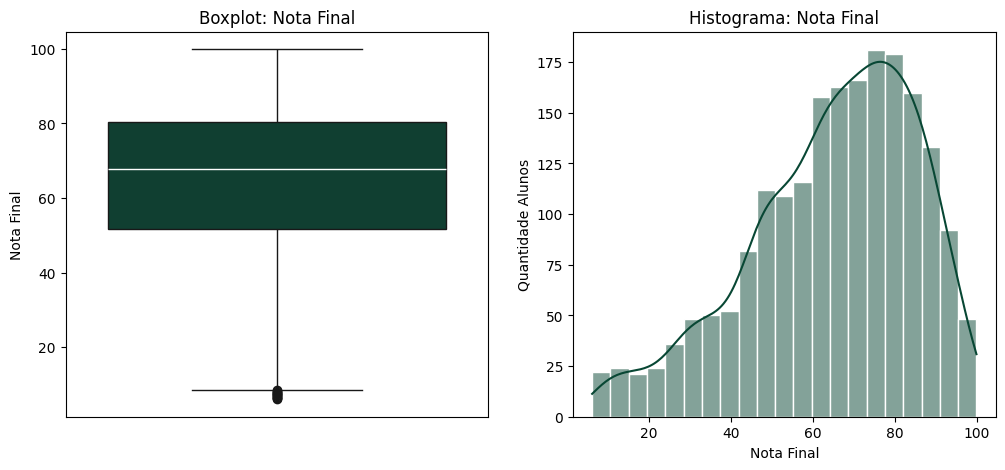

In [20]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(y=dados['nota_final'], color='#084734', medianprops=dict(color='white'))
plt.title('Boxplot: Nota Final')
plt.ylabel('Nota Final')
plt.xticks([])

plt.subplot(1, 2, 2)
sns.histplot(dados['nota_final'], kde=True, color='#084734', edgecolor='white')
plt.title('Histograma: Nota Final')
plt.xlabel('Nota Final')
plt.ylabel('Quantidade Alunos')

plt.show()

*Remoção ou substituição de valores atípicos na variável resposta, se houver*

In [21]:
# Remoção de linhas com valores atípicos, se houver (exemplo: cortando pelo P99)
# corte_outliers = dados['nota_final'].quantile(0.99)
# dados = dados[dados['nota_final'] <= corte_outliers]

# Ou substituição de valores atípicos, se houver (exemplo: substituindo pelo P99)
# corte_outliers = dados['nota_final'].quantile(0.99)
# dados.loc[dados['nota_final'] > corte_outliers, 'nota_final'] = corte_outliers

In [22]:
# plt.figure(figsize=(12, 5))

# plt.subplot(1, 2, 1)
# sns.boxplot(y=dados['nota_final'], color='#084734', medianprops=dict(color='white'))
# plt.title('Boxplot: Nota Final')
# plt.ylabel('Nota Final')
# plt.xticks([])

# plt.subplot(1, 2, 2)
# sns.histplot(dados['PRECO_REVENDA'], kde=True, color='#084734', edgecolor='white')
# plt.title('Histograma: Nota Final')
# plt.xlabel('Nota Final')
# plt.ylabel('Frequência')

# plt.show()

### **Definição de variáveis explicativas e variável resposta**

*Lista de nomes das variáveis explicativas, separando em quantitativas e qualitativas*

In [23]:
# Variáveis explicativas quantitativas
lista_X_quanti = ['horas_estudo_semana',
                  'frequencia_aulas_pct',
                  'media_notas_anteriores',
                  'atividades_extracurriculares',
                  'tempo_deslocamento_min',
                  'nro_irmaos'
                  ]

# Variáveis explicativas qualitativas
lista_X_quali = ['escolaridade_pais',
                 'acesso_internet_casa',
                 'participa_monitoria',
                 'trabalha_alem_estudar',
                 'turno',
                 'possui_transporte_proprio'
                 ]

*Objetos para variável resposta (y) e explicativas (X)*

In [24]:
y = dados['nota_final']
X = dados[lista_X_quanti + lista_X_quali]

### **Análise bivariada: variável resposta vs. variáveis explicativas**

*Correlograma para variáveis explicativas quantitativas (obs.: pode ser computacionalmente inviável para bases grandes em linhas ou colunas)*


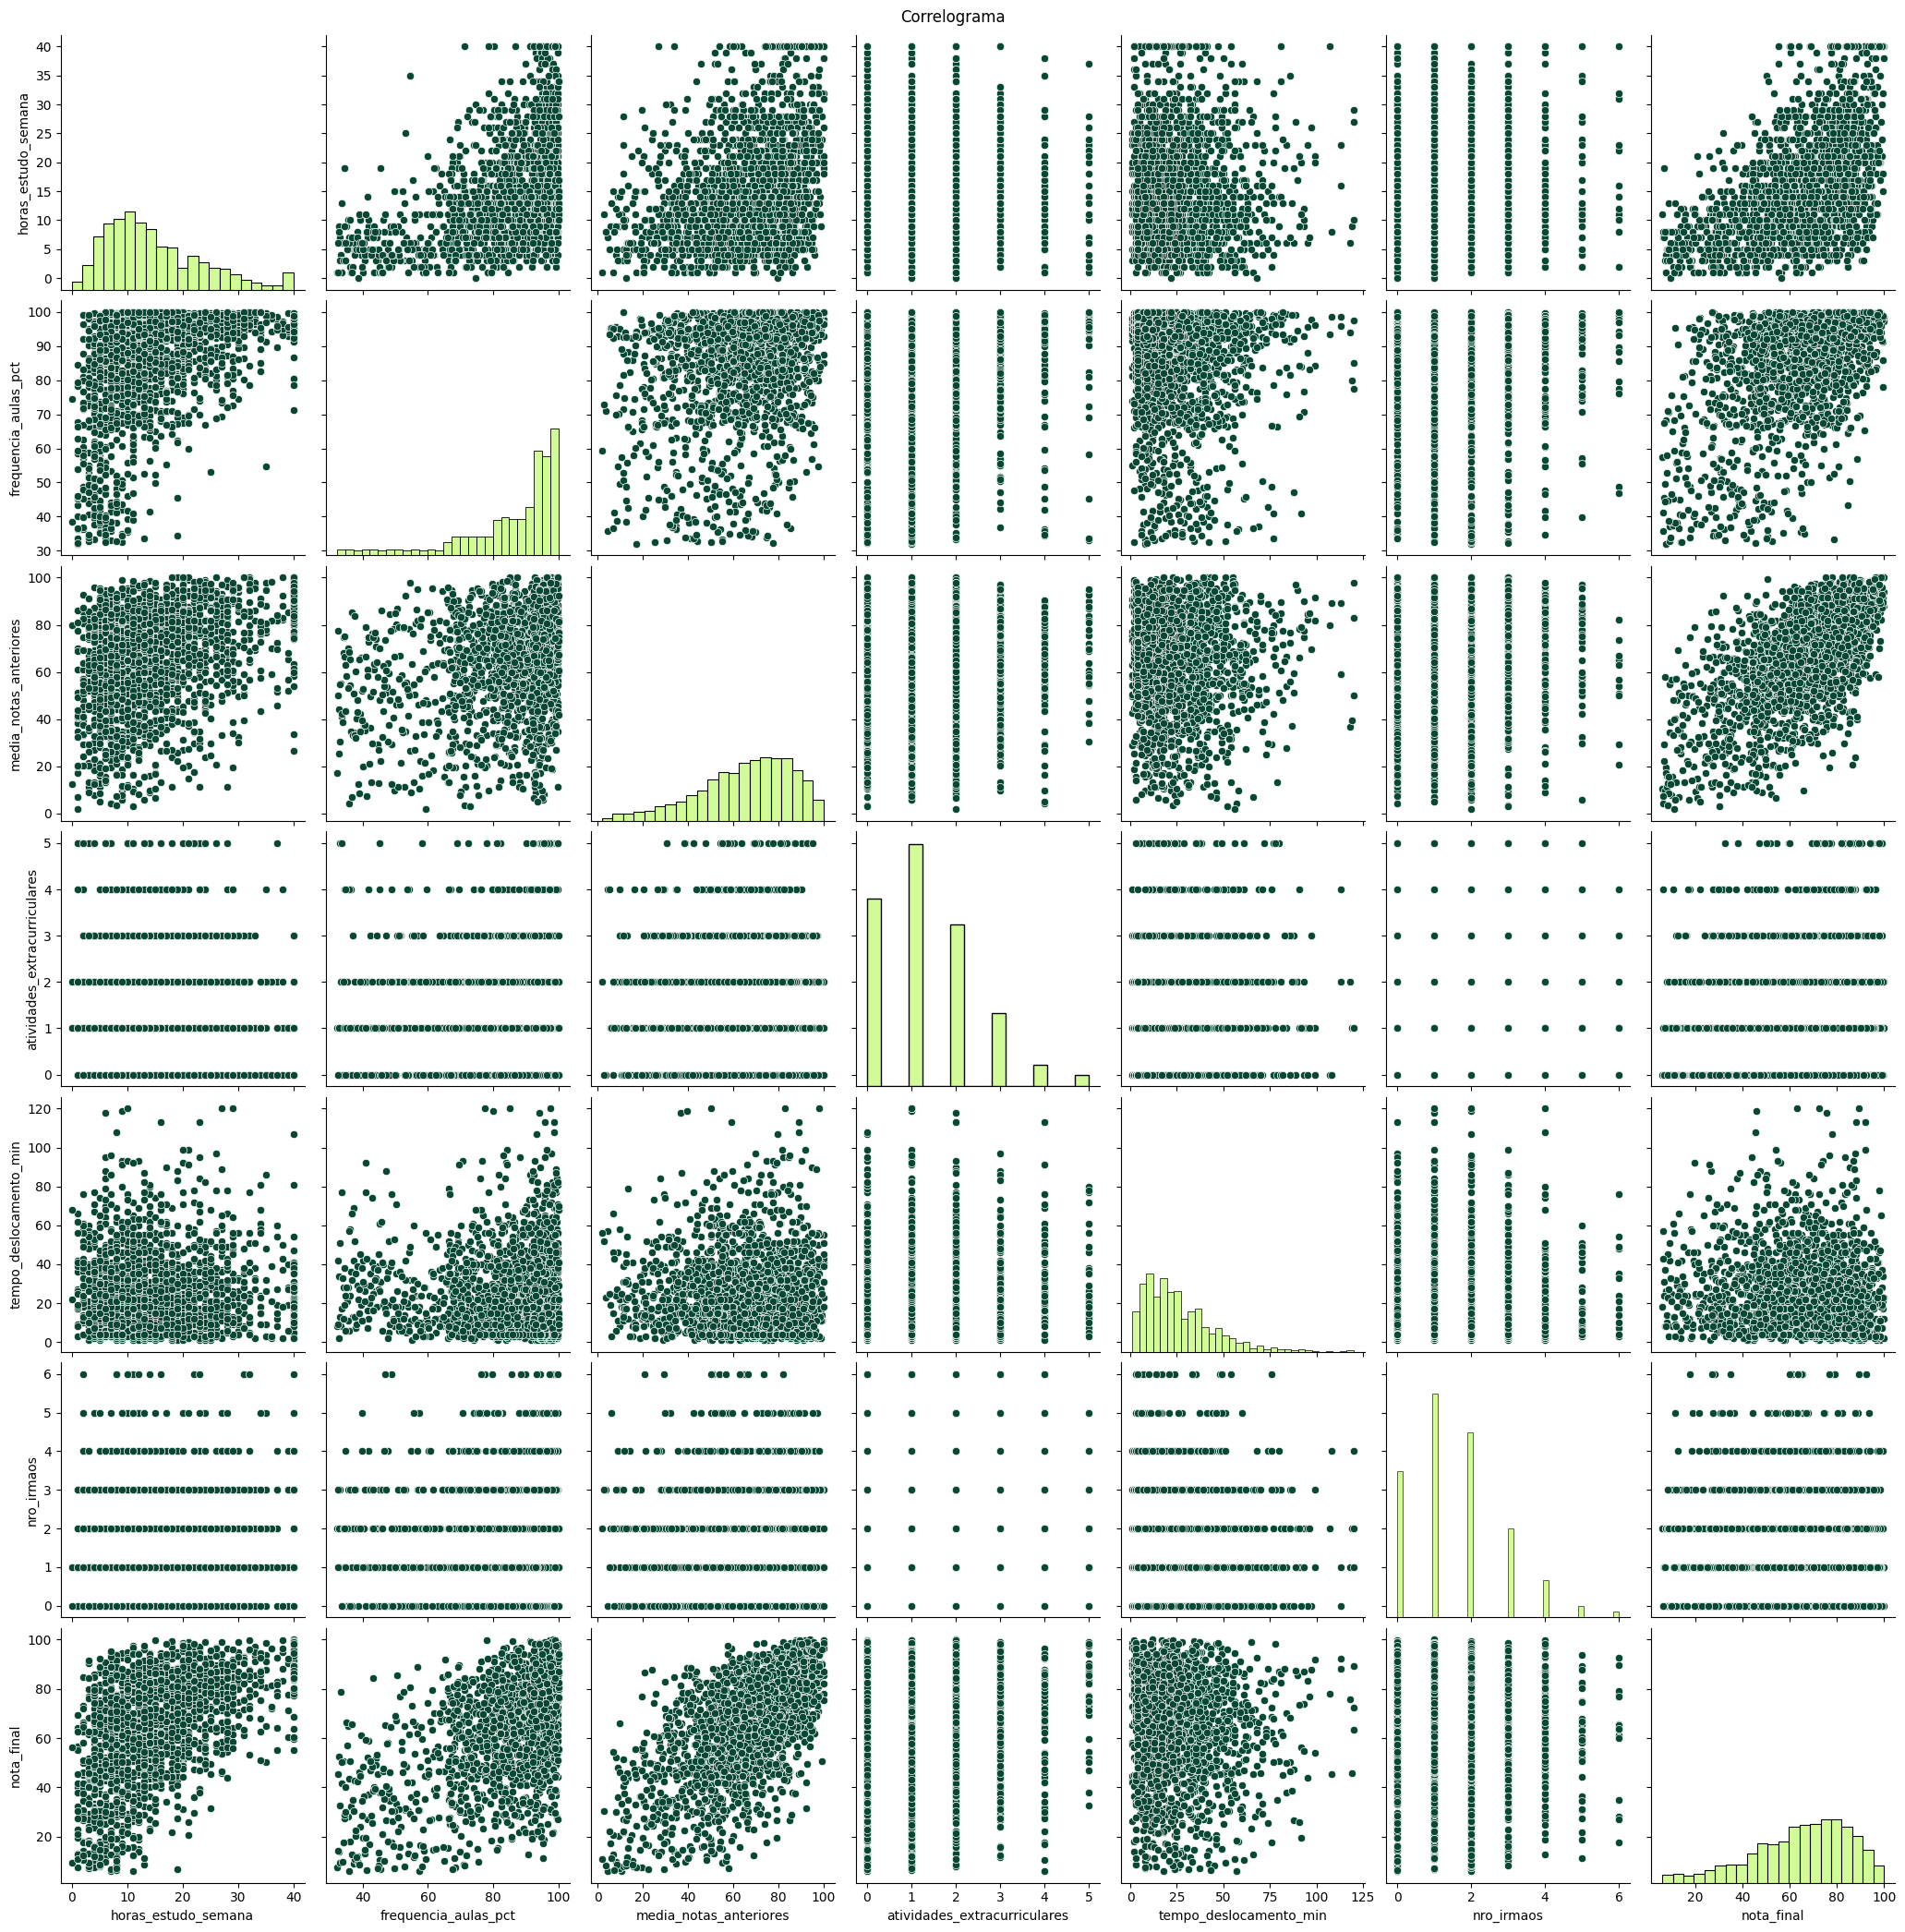

In [25]:
sns.pairplot(dados[lista_X_quanti + [y.name]],
             plot_kws={'color':'#084734'},
             diag_kws={'color':'#C3FA75'},
             height=3)
plt.suptitle("Correlograma", y=1)
plt.show()

*Matriz de correlações para variáveis quantitativas*

In [26]:
# Correlações lineares de Pearson
matriz_cor_pearson = (pd.concat([dados[lista_X_quanti], y], axis=1)).corr().round(3)
matriz_cor_pearson

,horas_estudo_semana,frequencia_aulas_pct,media_notas_anteriores,atividades_extracurriculares,tempo_deslocamento_min,nro_irmaos,nota_final
horas_estudo_semana,1.000,0.408,0.313,-0.048,0.014,0.015,0.484
frequencia_aulas_pct,0.408,1.000,0.284,0.005,-0.007,-0.033,0.514
media_notas_anteriores,0.313,0.284,1.000,-0.035,0.011,0.012,0.618
atividades_extracurriculares,-0.048,0.005,-0.035,1.000,0.019,-0.015,0.107
tempo_deslocamento_min,0.014,-0.007,0.011,0.019,1.000,-0.005,-0.044
nro_irmaos,0.015,-0.033,0.012,-0.015,-0.005,1.000,-0.069
nota_final,0.484,0.514,0.618,0.107,-0.044,-0.069,1.000


In [27]:
# Correlações de Spearman
matriz_cor_spearman = (pd.concat([dados[lista_X_quanti], y], axis=1)).corr(method='spearman').round(3)
matriz_cor_spearman

,horas_estudo_semana,frequencia_aulas_pct,media_notas_anteriores,atividades_extracurriculares,tempo_deslocamento_min,nro_irmaos,nota_final
horas_estudo_semana,1.000,0.420,0.319,-0.057,0.008,-0.007,0.496
frequencia_aulas_pct,0.420,1.000,0.273,0.007,-0.010,-0.035,0.444
media_notas_anteriores,0.319,0.273,1.000,-0.038,0.006,0.008,0.598
atividades_extracurriculares,-0.057,0.007,-0.038,1.000,-0.006,-0.032,0.116
tempo_deslocamento_min,0.008,-0.010,0.006,-0.006,1.000,-0.013,-0.044
nro_irmaos,-0.007,-0.035,0.008,-0.032,-0.013,1.000,-0.066
nota_final,0.496,0.444,0.598,0.116,-0.044,-0.066,1.000


*Gráfico de calor para representar a matriz de correlações (útil apenas para regressão múltipla)*

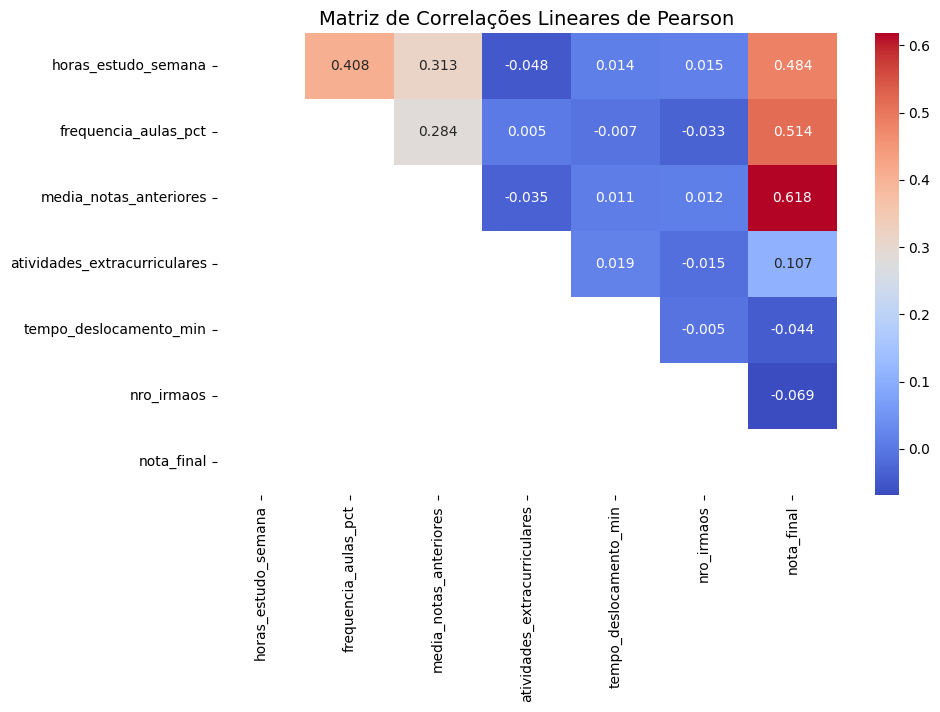

In [28]:
# Correlações lineares de Pearson
mask = np.tril(np.ones(matriz_cor_pearson.shape, dtype=bool))

plt.figure(figsize=(10, 6))
sns.heatmap(matriz_cor_pearson, mask=mask, annot=True, fmt=".3f", cmap="coolwarm")
plt.title("Matriz de Correlações Lineares de Pearson", fontsize=14)
plt.show()

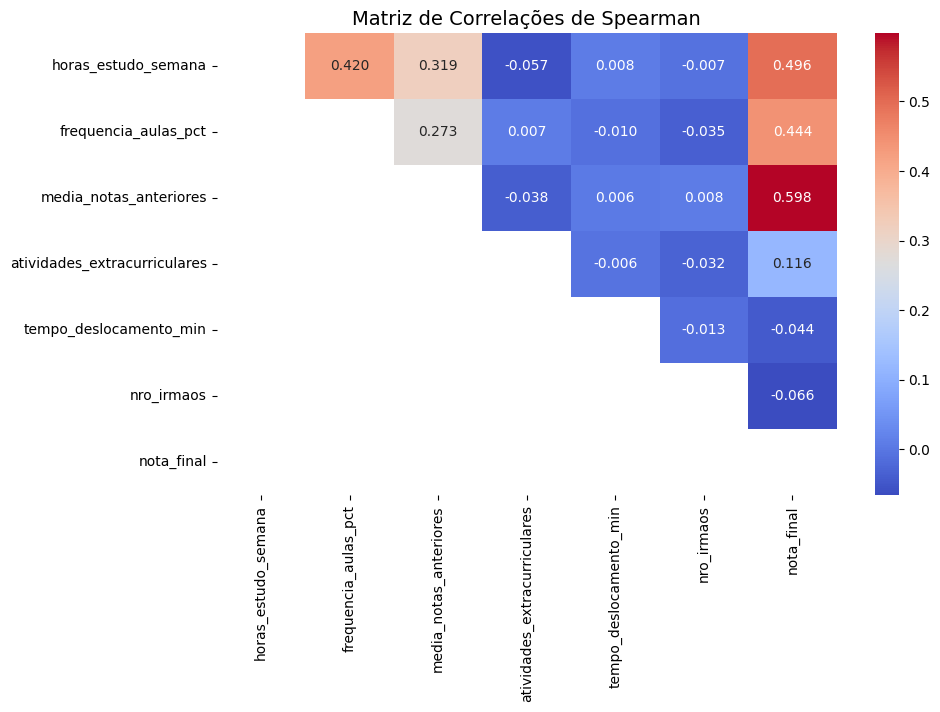

In [29]:
# Correlações de Spearman
mask = np.tril(np.ones(matriz_cor_spearman.shape, dtype=bool))

plt.figure(figsize=(10, 6))
sns.heatmap(matriz_cor_spearman, mask=mask, annot=True, fmt=".3f", cmap="coolwarm")
plt.title("Matriz de Correlações de Spearman", fontsize=14)
plt.show()

*Gráficos de boxplot para as variáveis qualitativas*

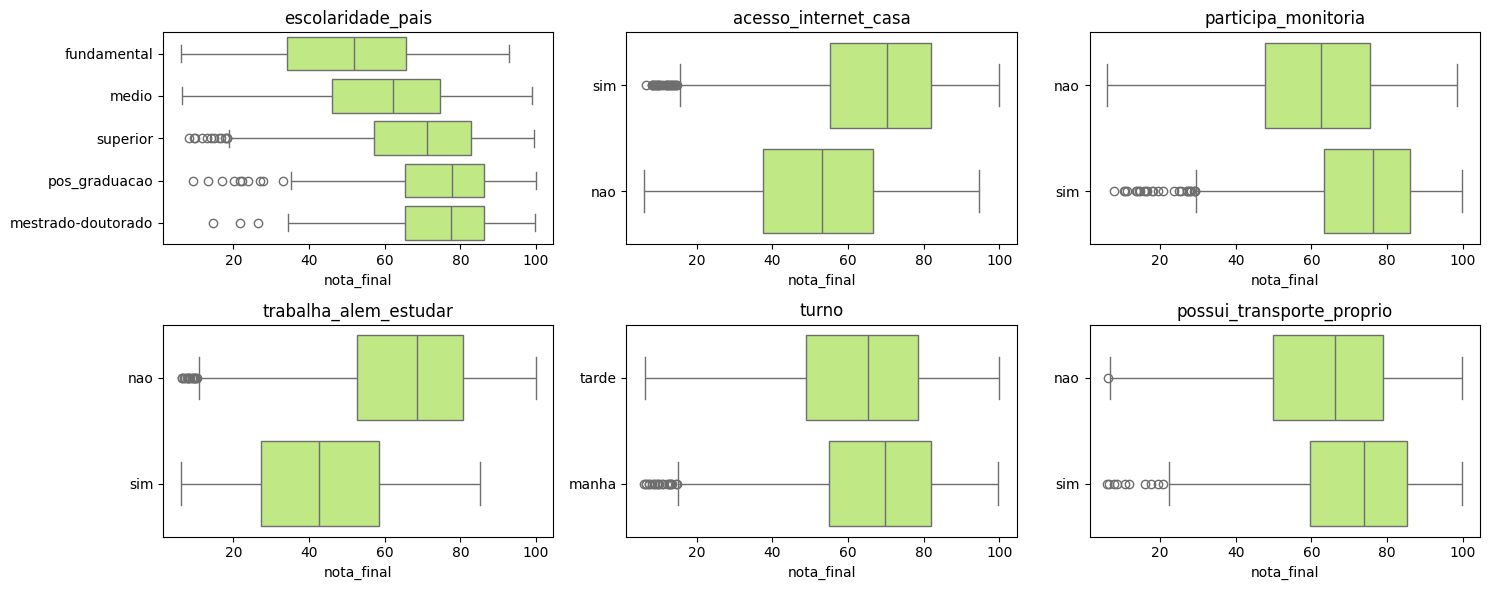

In [30]:
n = len(lista_X_quali)

if n == 0:
    pass  # saída omitida caso não haja variáveis qualitativas
else:
    ncols = 3
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3 * nrows))
    axes = axes.flatten()

    for ax, var in zip(axes, lista_X_quali):
        sns.boxplot(x=y.name, y=var, data=dados, ax=ax, color='#C3FA75')
        ax.set_title(var)
        ax.set_ylabel('')

    for ax in axes[n:]:
        ax.set_visible(False)

    plt.tight_layout()
    plt.show()

### **Transformação de variáveis e atualização da análise bivariada**

*Transformação de variáveis*

In [31]:
# Nenhuma transformação necessária, pois a relação entre as variáveis é linear. Para um exemplo de case onde a transformação foi necessária, vide arquivo 'Mensuracao_Cupons.ipynb'.

*Redefinição de objetos*

In [32]:
# Nenhuma transformação necessária, pois a relação entre as variáveis é linear. Para um exemplo de case onde a transformação foi necessária, vide arquivo 'Mensuracao_Cupons.ipynb'.

*Novo correlograma após transformação (obs.: pode ser computacionalmente inviável para bases grandes em linhas ou colunas)*


In [33]:
# Nenhuma transformação necessária, pois a relação entre as variáveis é linear. Para um exemplo de case onde a transformação foi necessária, vide arquivo 'Mensuracao_Cupons.ipynb'.

*Coeficiente de correlação linear de Pearson após transformação*

In [34]:
# Nenhuma transformação necessária, pois a relação entre as variáveis é linear. Para um exemplo de case onde a transformação foi necessária, vide arquivo 'Mensuracao_Cupons.ipynb'.

### **Divisão de treino e teste externo**

In [35]:
X_treino, X_teste_externo, y_treino, y_teste_externo = train_test_split(X, y, test_size=0.2, random_state=123)
X_treino.shape, X_teste_externo.shape

((1580, 12), (396, 12))

### **Pré-processamento**

In [36]:
# Criação de objeto da classe ColumnTransformer (padronização das quantitativas + codificação one-hot das qualitativas)
preprocessador = ColumnTransformer(transformers=[
    ("quanti", StandardScaler(), lista_X_quanti),
    ("quali", OneHotEncoder(sparse_output=False, drop="first", handle_unknown='ignore'), lista_X_quali)
], verbose_feature_names_out=False)
preprocessador.set_output(transform="pandas")

# Ajuste do pré-processamento com os dados de treino
X_treino = preprocessador.fit_transform(X_treino)

# Aplicação do pré-processamento no conjunto de teste externo
X_teste_externo = preprocessador.transform(X_teste_externo)

# Aplicação do pré-processamento na base completa
X = preprocessador.transform(X)

### **Construção do modelo (com validação cruzada e otimização de hiperparâmetros)**

*Definição da(s) técnica(s) de modelagem*

In [37]:
from sklearn.linear_model import SGDRegressor            # Ajuste de modelos de regressão linear regularizada
from scipy.stats import uniform, loguniform              # Geração de valores aleatórios (para os hiperparâmetros)

In [38]:
tecnicas = {

    'Reg. Linear': (LinearRegression(), {
    }),

    'Reg. Linear Regularizada': (SGDRegressor(random_state=123, max_iter=10000, tol=1e-2), {
        'penalty': ['l2', 'l1', 'elasticnet'],
        'alpha': loguniform(1e-5, 1e1),               # Peso da penalização
        'l1_ratio': uniform(0, 1),                    # Contribuição da penalização LASSO (L1) em relação a Ridge (L2)
        'eta0': loguniform(1e-4, 1e-1),               # Taxa de aprendizado inicial
        'learning_rate': ['constant',                 # Métodos de atualização de eta0
                          'invscaling',
                          'adaptive']
    })

}

*Estratégia de validação cruzada (k-fold), quantidade de iterações de busca e métricas de avaliação*

In [39]:
kf = KFold(n_splits=5, shuffle=True, random_state=123)    # Altere a quantidade de folds, se desejar
qtd_iteracoes = 100                                       # Altere a quantidade de iterações de busca aleatória, se desejar
lista_metricas = ['neg_root_mean_squared_error',          # Altere as métricas de avaliação, se desejar
                  'neg_mean_absolute_error',
                  'neg_mean_absolute_percentage_error',
                  'r2']
scorers = {metrica: get_scorer(metrica) for metrica in lista_metricas}
sinais = {metrica: -1 if metrica.startswith('neg_') else 1 for metrica in lista_metricas}

*Construção dos modelos*

In [40]:
resultados = []         # Lista para armazenar resultados
contador_modelos = 0    # Contador de modelos testados

for nome_tecnica, (classe_tecnica, hiperparametros) in tecnicas.items():

    # Início da contagem de tempo e de modelos
    inicio = time.time()

    # Busca aleatória de hiperparâmetros com validação cruzada (randomized search)
    busca = RandomizedSearchCV(
        estimator=classe_tecnica,
        param_distributions=hiperparametros,
        n_iter=1 if not hiperparametros else qtd_iteracoes,
        scoring=lista_metricas,
        refit=False,
        cv=kf,
        return_train_score=True,
        random_state=123,
        n_jobs=-1
    )

    # Ajuste dos modelos
    busca.fit(X_treino, y_treino)

    # Armazenar as informações básicas de cada modelo
    resultados_aux = pd.DataFrame({
        "num_modelo": [f"Modelo {contador_modelos + i}" for i in range(len(busca.cv_results_["params"]))],
        "nome_tecnica": nome_tecnica,
        "classe_tecnica": type(classe_tecnica).__name__,
        "hiperparametros": busca.cv_results_["params"]
    })

    # Calcular as métricas no teste externo, para cada modelo
    metricas_teste_externo = {metrica: [] for metrica in lista_metricas}
    for params in resultados_aux["hiperparametros"]:
        estimador = clone(classe_tecnica).set_params(**params)
        estimador.fit(X_treino, y_treino)
        for metrica in lista_metricas:
            metricas_teste_externo[metrica].append(sinais[metrica] * scorers[metrica](estimador, X_teste_externo, y_teste_externo))

    # Armazenar, para cada métrica: média e dp de treino e teste interno; teste externo; e variações em relação ao treino
    for metrica in lista_metricas:
        nome_metrica = metrica.replace('neg_', '')
        resultados_aux[f"{nome_metrica}_media_treino"] = sinais[metrica] * busca.cv_results_[f"mean_train_{metrica}"]
        resultados_aux[f"{nome_metrica}_dp_treino"] = busca.cv_results_[f"std_train_{metrica}"]
        resultados_aux[f"{nome_metrica}_media_teste_interno"] = sinais[metrica] * busca.cv_results_[f"mean_test_{metrica}"]
        resultados_aux[f"{nome_metrica}_dp_teste_interno"] = busca.cv_results_[f"std_test_{metrica}"]
        resultados_aux[f"{nome_metrica}_teste_externo"] = metricas_teste_externo[metrica]
        resultados_aux[f"{nome_metrica}_var_teste_interno"] = abs(resultados_aux[f"{nome_metrica}_media_teste_interno"] - resultados_aux[f"{nome_metrica}_media_treino"])
        resultados_aux[f"{nome_metrica}_var_perc_teste_interno"] = resultados_aux[f"{nome_metrica}_var_teste_interno"] / abs(resultados_aux[f"{nome_metrica}_media_treino"])
        resultados_aux[f"{nome_metrica}_var_teste_externo"] = abs(resultados_aux[f"{nome_metrica}_teste_externo"] - resultados_aux[f"{nome_metrica}_media_treino"])
        resultados_aux[f"{nome_metrica}_var_perc_teste_externo"] = resultados_aux[f"{nome_metrica}_var_teste_externo"] / abs(resultados_aux[f"{nome_metrica}_media_treino"])

    resultados.append(resultados_aux)
    contador_modelos += len(resultados_aux)

    # Fim da contagem de tempo e mensagem de finalização
    fim = time.time()
    print(f"({math.ceil(contador_modelos/qtd_iteracoes)} de {len(tecnicas)}) Processo concluído para a técnica {nome_tecnica} em {fim - inicio:.1f} segundos!")

# Criação de data frame com os resultados
resultados = pd.concat(resultados, ignore_index=True)

(1 de 2) Processo concluído para a técnica Reg. Linear em 2.8 segundos!
(2 de 2) Processo concluído para a técnica Reg. Linear Regularizada em 27.6 segundos!


*Resultados completos da execução*

In [41]:
resultados

,num_modelo,nome_tecnica,classe_tecnica,hiperparametros,root_mean_squared_error_media_treino,root_mean_squared_error_dp_treino,root_mean_squared_error_media_teste_interno,root_mean_squared_error_dp_teste_interno,root_mean_squared_error_teste_externo,root_mean_squared_error_var_teste_interno,...,mean_absolute_percentage_error_var_perc_teste_externo,r2_media_treino,r2_dp_treino,r2_media_teste_interno,r2_dp_teste_interno,r2_teste_externo,r2_var_teste_interno,r2_var_perc_teste_interno,r2_var_teste_externo,r2_var_perc_teste_externo
0,Modelo 0,Reg. Linear,LinearRegression,{},10.496175,0.090057,10.650078,0.356705,10.660887,0.153903,...,0.112757,0.735069,0.006414,0.725056,0.026814,0.735701,0.010012,0.013621,0.000633,0.000860
1,Modelo 1,Reg. Linear Regularizada,SGDRegressor,"{'alpha': 0.1509437424647132, 'eta0': 0.000721...",10.640139,0.092256,10.797782,0.425757,11.004875,0.157643,...,0.126244,0.727750,0.006647,0.717184,0.030313,0.718370,0.010566,0.014518,0.009380,0.012889
2,Modelo 2,Reg. Linear Regularizada,SGDRegressor,"{'alpha': 0.20740241962891853, 'eta0': 0.00185...",10.749087,0.092950,10.896347,0.457570,11.058150,0.147259,...,0.102384,0.722141,0.006995,0.711863,0.032431,0.715637,0.010277,0.014232,0.006504,0.009007
3,Modelo 3,Reg. Linear Regularizada,SGDRegressor,"{'alpha': 0.007684071705306552, 'eta0': 0.0015...",10.603927,0.095832,10.744522,0.435342,10.843120,0.140595,...,0.100744,0.729598,0.006759,0.720147,0.028699,0.726588,0.009451,0.012954,0.003010,0.004125
4,Modelo 4,Reg. Linear Regularizada,SGDRegressor,"{'alpha': 2.2806958885781183e-05, 'eta0': 0.00...",10.501388,0.090890,10.652109,0.379872,10.670765,0.150721,...,0.113205,0.734804,0.006490,0.724928,0.027447,0.735211,0.009876,0.013441,0.000407,0.000554
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,Modelo 96,Reg. Linear Regularizada,SGDRegressor,"{'alpha': 0.04697450737609354, 'eta0': 0.00041...",10.648284,0.098277,10.774479,0.405029,10.979880,0.126194,...,0.127180,0.727329,0.006922,0.718482,0.029116,0.719648,0.008848,0.012164,0.007682,0.010561
97,Modelo 97,Reg. Linear Regularizada,SGDRegressor,"{'alpha': 1.513979899474869, 'eta0': 0.0033744...",14.366271,0.111726,14.428600,0.294236,14.738694,0.062330,...,0.139221,0.503696,0.011250,0.496189,0.034521,0.494843,0.007507,0.014904,0.008853,0.017576
98,Modelo 98,Reg. Linear Regularizada,SGDRegressor,"{'alpha': 0.7866771541017803, 'eta0': 0.000930...",13.230459,0.102109,13.300541,0.317272,13.502775,0.070082,...,0.130067,0.579062,0.009877,0.571541,0.034912,0.576011,0.007521,0.012988,0.003051,0.005269
99,Modelo 99,Reg. Linear Regularizada,SGDRegressor,"{'alpha': 0.11303340641085656, 'eta0': 0.00687...",10.592499,0.093859,10.756707,0.409483,10.915155,0.164208,...,0.120507,0.730181,0.006690,0.719399,0.029249,0.722943,0.010782,0.014766,0.007238,0.009912


### **Comparação de modelos**

*Escolha de critérios*

In [42]:
# Preencha a quantidade de modelos que deseja comparar
# (aqui só existe 1 modelo no total, pois 'tecnicas' contém apenas 'Reg. Linear' sem hiperparâmetros)
qtd_modelos = 15

# Preencha uma métrica a ser considerada para seleção dos melhores modelos no conjunto de teste interno, entre as que foram listadas em 'lista_metricas'
ordenar_por = "neg_root_mean_squared_error"

# Preencha os limites máximos de variação percentual da métrica no teste interno e no teste externo, em comparação com o treino (ex.: 0.1 representa 10%)
limite_var_perc_metrica_teste_interno = 0.1
limite_var_perc_metrica_teste_externo = 0.1

*Ordenação e filtragem dos melhores modelos*

In [43]:
nome_metrica_ordenacao = ordenar_por.replace('neg_', '')
crescente = ordenar_por.startswith('neg_')
resultados_filt_ord = resultados[(resultados[f'{nome_metrica_ordenacao}_var_perc_teste_interno'] < limite_var_perc_metrica_teste_interno) & (resultados[f'{nome_metrica_ordenacao}_var_perc_teste_externo'] < limite_var_perc_metrica_teste_externo)]
resultados_filt_ord = resultados_filt_ord.sort_values(f'{nome_metrica_ordenacao}_media_teste_interno', ascending=crescente).head(qtd_modelos)

*Exibição dos melhores modelos, em forma de tabela*

In [44]:
pd.set_option('display.float_format', '{:.3f}'.format)   # Quantidade de casas decimais
resultados_filt_ord[['num_modelo',
                     'nome_tecnica',
                     'hiperparametros',
                     f'{nome_metrica_ordenacao}_media_treino',
                     f'{nome_metrica_ordenacao}_dp_treino',
                     f'{nome_metrica_ordenacao}_media_teste_interno',
                     f'{nome_metrica_ordenacao}_dp_teste_interno',
                     f'{nome_metrica_ordenacao}_var_perc_teste_interno',
                     f'{nome_metrica_ordenacao}_teste_externo',
                     f'{nome_metrica_ordenacao}_var_perc_teste_externo']]

,num_modelo,nome_tecnica,hiperparametros,root_mean_squared_error_media_treino,root_mean_squared_error_dp_treino,root_mean_squared_error_media_teste_interno,root_mean_squared_error_dp_teste_interno,root_mean_squared_error_var_perc_teste_interno,root_mean_squared_error_teste_externo,root_mean_squared_error_var_perc_teste_externo
43,Modelo 43,Reg. Linear Regularizada,"{'alpha': 0.00396857022487126, 'eta0': 0.00304...",10.498,0.091,10.649,0.371,0.014,10.668,0.016
72,Modelo 72,Reg. Linear Regularizada,"{'alpha': 0.0015186507463832806, 'eta0': 0.004...",10.498,0.090,10.650,0.364,0.014,10.681,0.017
0,Modelo 0,Reg. Linear,{},10.496,0.090,10.650,0.357,0.015,10.661,0.016
22,Modelo 22,Reg. Linear Regularizada,"{'alpha': 0.001910065612339858, 'eta0': 0.0044...",10.497,0.090,10.650,0.362,0.015,10.668,0.016
24,Modelo 24,Reg. Linear Regularizada,"{'alpha': 0.000569541823936819, 'eta0': 0.0194...",10.496,0.090,10.650,0.356,0.015,10.657,0.015
25,Modelo 25,Reg. Linear Regularizada,"{'alpha': 1.5015589997501383e-05, 'eta0': 0.00...",10.496,0.090,10.651,0.361,0.015,10.665,0.016
9,Modelo 9,Reg. Linear Regularizada,"{'alpha': 0.0007474245141964294, 'eta0': 0.001...",10.499,0.090,10.651,0.372,0.014,10.676,0.017
92,Modelo 92,Reg. Linear Regularizada,"{'alpha': 0.0001836182167489801, 'eta0': 0.001...",10.499,0.090,10.651,0.373,0.014,10.671,0.016
80,Modelo 80,Reg. Linear Regularizada,"{'alpha': 0.00017246094928597753, 'eta0': 0.00...",10.506,0.091,10.651,0.384,0.014,10.688,0.017
55,Modelo 55,Reg. Linear Regularizada,"{'alpha': 0.000268843434102392, 'eta0': 0.0265...",10.496,0.090,10.652,0.356,0.015,10.656,0.015


*Exibição dos melhores modelos, em forma de gráfico*

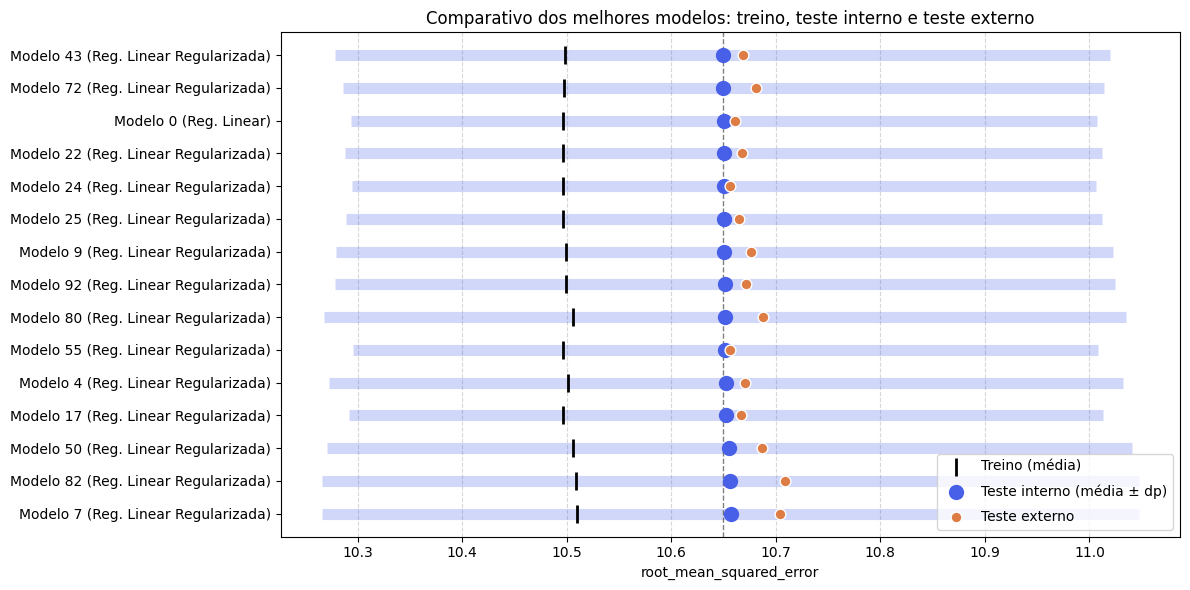

In [45]:
dados_grafico = resultados_filt_ord.iloc[::-1]   # Inversão para o melhor modelo ficar no topo
y_pos = np.arange(len(dados_grafico))            # Posições dos rótulos do eixo Y

plt.figure(figsize=(12, 6))

# Faixa de variabilidade entre folds (média ± dp do teste interno)
plt.errorbar(dados_grafico[f"{nome_metrica_ordenacao}_media_teste_interno"], y_pos,
             xerr=dados_grafico[f"{nome_metrica_ordenacao}_dp_teste_interno"],
             fmt='none', ecolor='#4860E7', elinewidth=8, alpha=0.25)

# Pontos de treino, teste interno e teste externo
plt.scatter(dados_grafico[f"{nome_metrica_ordenacao}_media_treino"], y_pos,
            color='black', marker='|', s=150, linewidths=2, label='Treino (média)', zorder=4)
plt.scatter(dados_grafico[f"{nome_metrica_ordenacao}_media_teste_interno"], y_pos,
            color="#4860E7", s=100, label='Teste interno (média ± dp)', zorder=3)
plt.scatter(dados_grafico[f"{nome_metrica_ordenacao}_teste_externo"], y_pos,
            color="#DD7D45", edgecolor='white', s=60, label='Teste externo', zorder=3)

# Linha de referência no melhor modelo
plt.axvline(dados_grafico[f"{nome_metrica_ordenacao}_media_teste_interno"].iloc[-1],
            color='black', linestyle='--', linewidth=1, alpha=0.5)

plt.yticks(y_pos, dados_grafico["num_modelo"] + " (" + dados_grafico["nome_tecnica"] + ")")
plt.xlabel(nome_metrica_ordenacao)
plt.title("Comparativo dos melhores modelos: treino, teste interno e teste externo")
plt.legend(loc='lower right', labelspacing=0.8)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### **Análise diagnóstica**

*Escolha do modelo*

In [46]:
# Seleção automática do melhor modelo dentre os já filtrados/ordenados na etapa de comparação
num_modelo_escolhido = int(resultados_filt_ord.iloc[0]['num_modelo'].split()[-1])
linha_modelo_escolhido = resultados.loc[resultados["num_modelo"] == 'Modelo ' + str(num_modelo_escolhido)].squeeze()
print(f"Modelo escolhido automaticamente: Modelo {num_modelo_escolhido} ({linha_modelo_escolhido['nome_tecnica']})")

Modelo escolhido automaticamente: Modelo 43 (Reg. Linear Regularizada)


*Escolha do modelo MANUAL - Para testar outros modelos*

In [47]:
num_modelo_escolhido = 43   # Preencha aqui o número do modelo que deseja analisar
linha_modelo_escolhido = resultados.loc[resultados["num_modelo"] == 'Modelo ' + str(num_modelo_escolhido)].squeeze()

*Medidas de qualidade de ajuste*

In [48]:
# Montagem da tabela de desempenho a partir dos resultados já calculados
tabela_desempenho = {}
for metrica in lista_metricas:
    nome_metrica = metrica.replace('neg_', '')
    tabela_desempenho[nome_metrica] = {
        'Treino (média)': linha_modelo_escolhido[f"{nome_metrica}_media_treino"],
        'Treino (dp)': linha_modelo_escolhido[f"{nome_metrica}_dp_treino"],
        'Teste interno (média)': linha_modelo_escolhido[f"{nome_metrica}_media_teste_interno"],
        'Teste interno (dp)': linha_modelo_escolhido[f"{nome_metrica}_dp_teste_interno"],
        'Teste externo': linha_modelo_escolhido[f"{nome_metrica}_teste_externo"]
    }
tabela_desempenho = pd.DataFrame(tabela_desempenho).T

print(f"-------------------------- Medidas de qualidade de ajuste: MODELO {num_modelo_escolhido} --------------------------")
tabela_desempenho.round(3)

-------------------------- Medidas de qualidade de ajuste: MODELO 43 --------------------------


,Treino (média),Treino (dp),Teste interno (média),Teste interno (dp),Teste externo
root_mean_squared_error,10.498,0.091,10.649,0.371,10.668
mean_absolute_error,8.259,0.090,8.382,0.333,8.477
mean_absolute_percentage_error,0.178,0.002,0.181,0.011,0.198
r2,0.735,0.006,0.725,0.027,0.735


*Reajuste do modelo escolhido no conjunto de treino completo*

In [49]:
modelo_escolhido = clone(tecnicas[linha_modelo_escolhido["nome_tecnica"]][0]).set_params(**linha_modelo_escolhido["hiperparametros"])
modelo_escolhido.fit(X_treino, y_treino)

SGDRegressor(alpha=np.float64(0.00396857022487126),
             eta0=np.float64(0.00304081637207441),
             l1_ratio=np.float64(0.4957404718670573), learning_rate='adaptive',
             max_iter=10000, penalty='l1', random_state=123, tol=0.01)

*Gráficos dos resíduos no conjunto de treino*

In [50]:
# Obtenção dos valores preditos e dos resíduos
y_hat_treino = modelo_escolhido.predict(X_treino)
resid_treino = y_treino - y_hat_treino

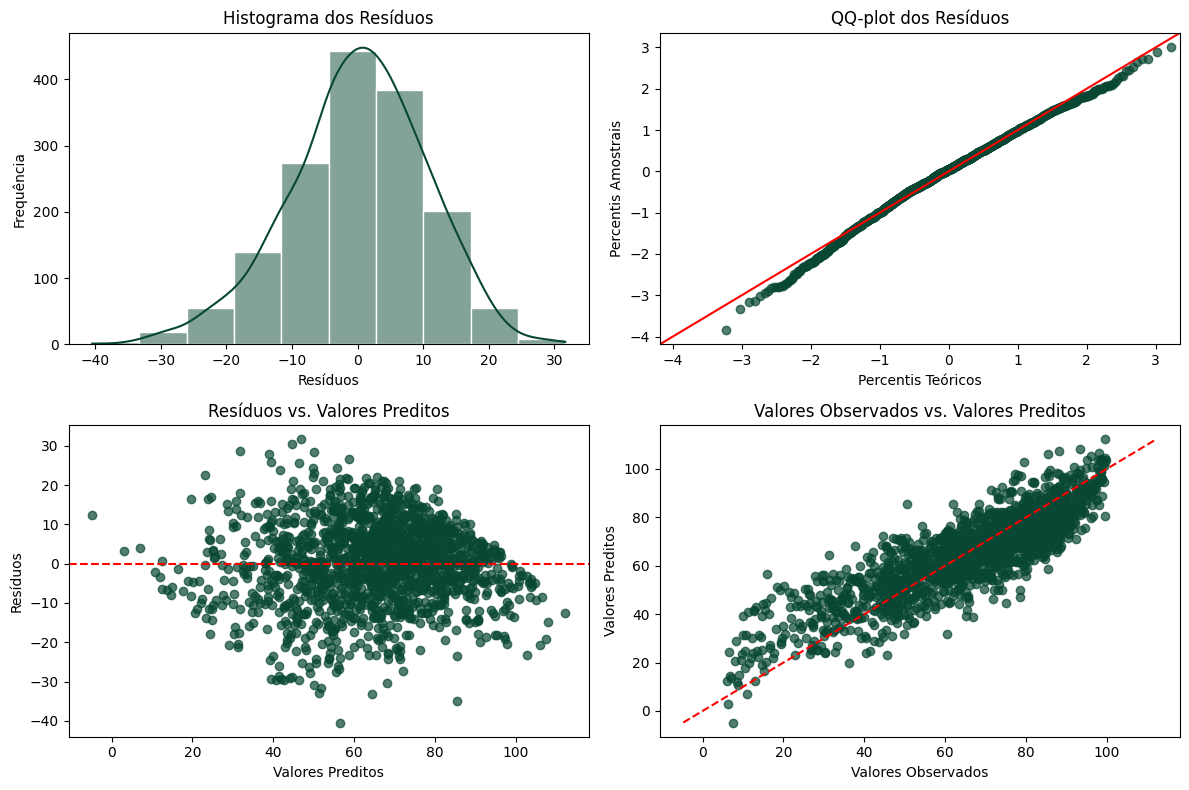

In [51]:
# Gráficos
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(resid_treino,
             bins=10,
             color="#084734",
             edgecolor="white",
             kde=True,
             ax=axes[0, 0])
axes[0, 0].set_title("Histograma dos Resíduos")
axes[0, 0].set_xlabel("Resíduos")
axes[0, 0].set_ylabel("Frequência")

sm.qqplot(resid_treino,
          line='45',
          fit=True,
          markerfacecolor='#084734',
          markeredgecolor='#084734',
          alpha=0.7,
          ax=axes[0, 1])
axes[0, 1].set_title("QQ-plot dos Resíduos")
axes[0, 1].set_xlabel("Percentis Teóricos")
axes[0, 1].set_ylabel("Percentis Amostrais")

axes[1, 0].scatter(y_hat_treino,
                   resid_treino,
                   color="#084734",
                   alpha=0.7)
axes[1, 0].axhline(0, color='red', linestyle='--')
axes[1, 0].set_title("Resíduos vs. Valores Preditos")
axes[1, 0].set_xlabel("Valores Preditos")
axes[1, 0].set_ylabel("Resíduos")

axes[1, 1].scatter(y_treino,
                   y_hat_treino,
                   color="#084734",
                   alpha=0.7)
axes[1, 1].plot([y_hat_treino.min(), y_hat_treino.max()], [y_hat_treino.min(), y_hat_treino.max()], color='red', linestyle='--')
axes[1, 1].set_title("Valores Observados vs. Valores Preditos")
axes[1, 1].set_xlabel("Valores Observados")
axes[1, 1].set_ylabel("Valores Preditos")

plt.tight_layout()
plt.show()

*Gráficos dos resíduos no conjunto de teste externo*

In [52]:
# Obtenção dos valores preditos e dos resíduos
y_hat_teste_externo = modelo_escolhido.predict(X_teste_externo)
resid_teste_externo = y_teste_externo - y_hat_teste_externo

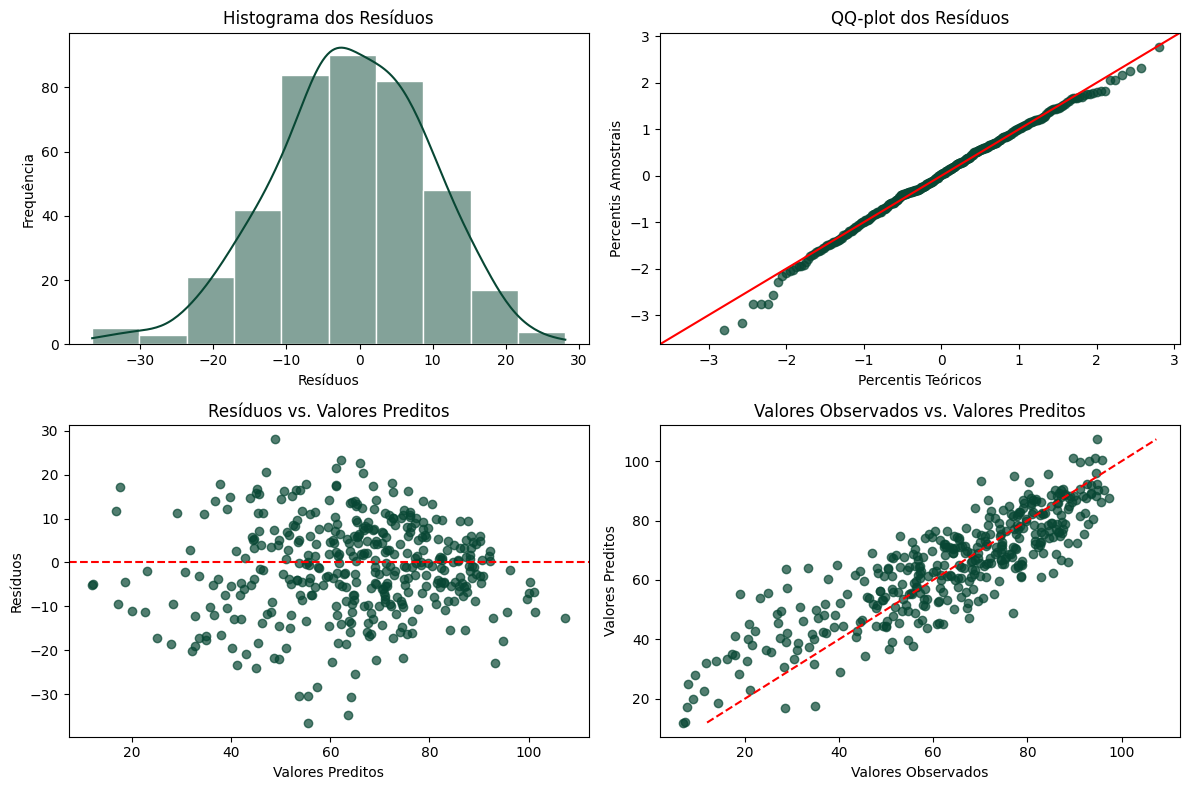

In [53]:
# Gráficos
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(resid_teste_externo,
             bins=10,
             color="#084734",
             edgecolor="white",
             kde=True,
             ax=axes[0, 0])
axes[0, 0].set_title("Histograma dos Resíduos")
axes[0, 0].set_xlabel("Resíduos")
axes[0, 0].set_ylabel("Frequência")

sm.qqplot(resid_teste_externo,
          line='45',
          fit=True,
          markerfacecolor='#084734',
          markeredgecolor='#084734',
          alpha=0.7,
          ax=axes[0, 1])
axes[0, 1].set_title("QQ-plot dos Resíduos")
axes[0, 1].set_xlabel("Percentis Teóricos")
axes[0, 1].set_ylabel("Percentis Amostrais")

axes[1, 0].scatter(y_hat_teste_externo,
                   resid_teste_externo,
                   color="#084734",
                   alpha=0.7)
axes[1, 0].axhline(0, color='red', linestyle='--')
axes[1, 0].set_title("Resíduos vs. Valores Preditos")
axes[1, 0].set_xlabel("Valores Preditos")
axes[1, 0].set_ylabel("Resíduos")

axes[1, 1].scatter(y_teste_externo,
                   y_hat_teste_externo,
                   color="#084734",
                   alpha=0.7)
axes[1, 1].plot([y_hat_teste_externo.min(), y_hat_teste_externo.max()], [y_hat_teste_externo.min(), y_hat_teste_externo.max()], color='red', linestyle='--')
axes[1, 1].set_title("Valores Observados vs. Valores Preditos")
axes[1, 1].set_xlabel("Valores Observados")
axes[1, 1].set_ylabel("Valores Preditos")

plt.tight_layout()
plt.show()

### **Viés do modelo por subgrupo**

*Objetivo: verificar se o modelo erra de forma uniforme entre os alunos ou se apresenta viés sistemático em algum subgrupo — em particular, alunos com nota histórica baixa. Análise feita sobre o conjunto de teste externo (fora da amostra), para não inflar artificialmente a precisão do modelo nos casos que ele já viu no treino.*

*Viés por faixa de nota histórica (`media_notas_anteriores`)*

In [54]:
# Nota histórica de cada aluno do teste externo, alinhada por índice aos resíduos já calculados
nota_historica_teste = dados.loc[X_teste_externo.index, 'media_notas_anteriores']

analise_vies = pd.DataFrame({
    'media_notas_anteriores': nota_historica_teste,
    'trabalha_alem_estudar': dados.loc[X_teste_externo.index, 'trabalha_alem_estudar'],
    'turno': dados.loc[X_teste_externo.index, 'turno'],
    'nota_final_real': y_teste_externo,
    'nota_final_prevista': y_hat_teste_externo,
    'residuo': resid_teste_externo,          # residuo = nota_final_real - nota_final_prevista
})
analise_vies['erro_absoluto'] = analise_vies['residuo'].abs()

faixas = [0, 20, 40, 60, 80, 100]
rotulos_faixas = ['0-20', '20-40', '40-60', '60-80', '80-100']
analise_vies['faixa_nota_historica'] = pd.cut(
    analise_vies['media_notas_anteriores'],
    bins=faixas, labels=rotulos_faixas, include_lowest=True
)

resumo_vies_nota_historica = analise_vies.groupby('faixa_nota_historica', observed=True).agg(
    n_alunos=('residuo', 'count'),
    erro_medio_absoluto=('erro_absoluto', 'mean'),
    vies_medio=('residuo', 'mean')   # positivo = modelo SUBESTIMA a nota; negativo = modelo SUPERESTIMA a nota
).round(2)

print(resumo_vies_nota_historica)

                      n_alunos  erro_medio_absoluto  vies_medio
faixa_nota_historica                                           
0-20                        19               14.290      -7.380
20-40                       35               10.210      -1.330
40-60                       84                8.250      -2.120
60-80                      150                8.560      -0.660
80-100                     108                6.940      -0.280


*Gráfico: erro médio absoluto e viés médio por faixa de nota histórica*

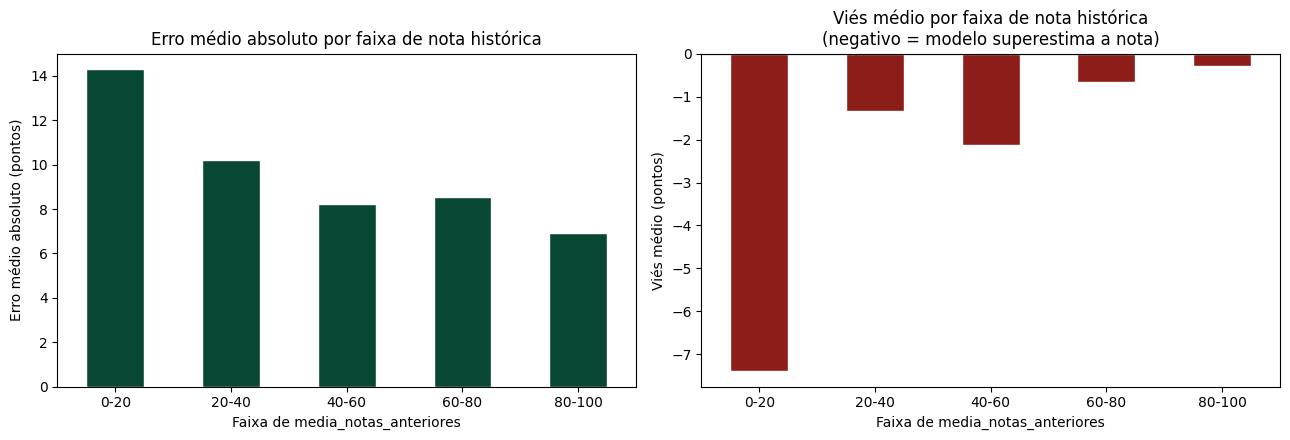

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

resumo_vies_nota_historica['erro_medio_absoluto'].plot(kind='bar', ax=axes[0], color='#084734', edgecolor='white')
axes[0].set_title('Erro médio absoluto por faixa de nota histórica')
axes[0].set_xlabel('Faixa de media_notas_anteriores')
axes[0].set_ylabel('Erro médio absoluto (pontos)')
axes[0].tick_params(axis='x', rotation=0)

cores = ['#8C1D18' if v < 0 else '#084734' for v in resumo_vies_nota_historica['vies_medio']]
resumo_vies_nota_historica['vies_medio'].plot(kind='bar', ax=axes[1], color=cores, edgecolor='white')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Viés médio por faixa de nota histórica\n(negativo = modelo superestima a nota)')
axes[1].set_xlabel('Faixa de media_notas_anteriores')
axes[1].set_ylabel('Viés médio (pontos)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

*Foco específico: alunos com nota histórica abaixo de 20 (grupo de maior risco)*

In [56]:
grupo_risco = analise_vies[analise_vies['media_notas_anteriores'] < 20]

print(f"Alunos no teste externo com media_notas_anteriores < 20: {len(grupo_risco)}")
print(f"Erro médio absoluto nesse grupo: {grupo_risco['erro_absoluto'].mean():.2f} pontos")
print(f"Viés médio nesse grupo: {grupo_risco['residuo'].mean():.2f} pontos "
      f"({'modelo subestima' if grupo_risco['residuo'].mean() > 0 else 'modelo superestima'} a nota, em média)")
print(f"Para comparação, erro médio absoluto no teste externo completo: {analise_vies['erro_absoluto'].mean():.2f} pontos")

if len(grupo_risco) < 30:
    print()
    print(f"Atenção: apenas {len(grupo_risco)} alunos nessa faixa no conjunto de teste — "
          "amostra pequena, resultado sujeito a alta variância. Tratar como indício, não como número definitivo.")

Alunos no teste externo com media_notas_anteriores < 20: 19
Erro médio absoluto nesse grupo: 14.29 pontos
Viés médio nesse grupo: -7.38 pontos (modelo superestima a nota, em média)
Para comparação, erro médio absoluto no teste externo completo: 8.48 pontos

Atenção: apenas 19 alunos nessa faixa no conjunto de teste — amostra pequena, resultado sujeito a alta variância. Tratar como indício, não como número definitivo.


*Viés por outros subgrupos sensíveis: `trabalha_alem_estudar` e `turno`*

In [57]:
resumo_vies_trabalha = analise_vies.groupby('trabalha_alem_estudar', observed=True).agg(
    n_alunos=('residuo', 'count'),
    erro_medio_absoluto=('erro_absoluto', 'mean'),
    vies_medio=('residuo', 'mean')
).round(2)

resumo_vies_turno = analise_vies.groupby('turno', observed=True).agg(
    n_alunos=('residuo', 'count'),
    erro_medio_absoluto=('erro_absoluto', 'mean'),
    vies_medio=('residuo', 'mean')
).round(2)

print("=== Viés por trabalha_alem_estudar ===")
print(resumo_vies_trabalha)
print()
print("=== Viés por turno ===")
print(resumo_vies_turno)

=== Viés por trabalha_alem_estudar ===
                       n_alunos  erro_medio_absoluto  vies_medio
trabalha_alem_estudar                                           
nao                         379                8.360      -1.150
sim                          17               10.970      -3.430

=== Viés por turno ===
       n_alunos  erro_medio_absoluto  vies_medio
turno                                           
manha       214                7.850      -1.110
tarde       182                9.210      -1.420


*Interpretação a documentar no relatório final: se o modelo apresenta viés relevante para algum subgrupo — em especial nota histórica baixa —, isso significa que ele não deve ser usado sozinho para decidir quem recebe apoio pedagógico sem revisão humana, sobretudo nos casos mais críticos. Um modelo que subestima o risco justamente do aluno mais vulnerável é um problema de uso, não só de precisão agregada (R²/RMSE).*

### **Reajuste final do modelo**

*Reajuste do modelo na base completa (100% das observações)*

In [58]:
modelo_final = clone(tecnicas[linha_modelo_escolhido["nome_tecnica"]][0]).set_params(**linha_modelo_escolhido["hiperparametros"])
modelo_final.fit(X, y)

SGDRegressor(alpha=np.float64(0.00396857022487126),
             eta0=np.float64(0.00304081637207441),
             l1_ratio=np.float64(0.4957404718670573), learning_rate='adaptive',
             max_iter=10000, penalty='l1', random_state=123, tol=0.01)

*Coeficientes do modelo escolhido*

In [59]:
pd.DataFrame({
    'NOME_VARIAVEL': modelo_final.feature_names_in_,
    'COEF_ESTIMADO': modelo_final.coef_,
    'COEF_ESTIMADO_ABS': np.abs(modelo_final.coef_)
}).sort_values(by='COEF_ESTIMADO_ABS', ascending=False)

,NOME_VARIAVEL,COEF_ESTIMADO,COEF_ESTIMADO_ABS
8,escolaridade_pais_pos_graduacao,11.782,11.782
12,trabalha_alem_estudar_sim,-8.998,8.998
9,escolaridade_pais_superior,8.894,8.894
11,participa_monitoria_sim,8.734,8.734
2,media_notas_anteriores,8.383,8.383
7,escolaridade_pais_mestrado-doutorado,8.380,8.380
14,possui_transporte_proprio_sim,7.945,7.945
10,acesso_internet_casa_sim,7.345,7.345
1,frequencia_aulas_pct,5.803,5.803
13,turno_tarde,-4.466,4.466


### **Utilização do modelo em nova base de dados**

*Criação de novo objeto 'Estudante 1'*

In [93]:
# Os nomes das colunas e tipos das variáveis devem ser idênticos aos da base utilizada para o modelo; caso tenham sido realizados tratamento de ausentes, outliers etc., os mesmos devem ser refletidos na nova base
X_estudante1 = pd.DataFrame({
    'horas_estudo_semana': [8],
    'frequencia_aulas_pct': [80],
    'media_notas_anteriores': [52],
    'atividades_extracurriculares': [0],
    'tempo_deslocamento_min': [60],
    'nro_irmaos': [4],
    'escolaridade_pais': ["fundamental"],
    'acesso_internet_casa': ["sim"],
    'participa_monitoria': ["nao"],
    'trabalha_alem_estudar': ["sim"],
    'turno': ["tarde"],
    'possui_transporte_proprio': ["nao"],

})

*Pré-processamento*

In [94]:
X_estudante1 = preprocessador.transform(X_estudante1)

*Aplicação do modelo final*

In [95]:
modelo_final.predict(X_estudante1)

array([24.97717308])

*Criação de novo objeto 'Estudante 2'*

In [96]:
# Os nomes das colunas e tipos das variáveis devem ser idênticos aos da base utilizada para o modelo; caso tenham sido realizados tratamento de ausentes, outliers etc., os mesmos devem ser refletidos na nova base
X_estudante2 = pd.DataFrame({
    'horas_estudo_semana': [14],
    'frequencia_aulas_pct': [85],
    'media_notas_anteriores': [65],
    'atividades_extracurriculares': [1],
    'tempo_deslocamento_min': [25],
    'nro_irmaos': [2],
    'escolaridade_pais': ["superior"],
    'acesso_internet_casa': ["sim"],
    'participa_monitoria': ["nao"],
    'trabalha_alem_estudar': ["nao"],
    'turno': ["manha"],
    'possui_transporte_proprio': ["nao"],

})

*Pré-processamento*

In [97]:
X_estudante2 = preprocessador.transform(X_estudante2)

*Aplicação do modelo final*

In [98]:
modelo_final.predict(X_estudante2)

array([63.85433848])

*Criação de novo objeto 'Estudante 3'*

In [99]:
# Os nomes das colunas e tipos das variáveis devem ser idênticos aos da base utilizada para o modelo; caso tenham sido realizados tratamento de ausentes, outliers etc., os mesmos devem ser refletidos na nova base
X_estudante3 = pd.DataFrame({
    'horas_estudo_semana': [20],
    'frequencia_aulas_pct': [100],
    'media_notas_anteriores': [90],
    'atividades_extracurriculares': [0],
    'tempo_deslocamento_min': [15],
    'nro_irmaos': [0],
    'escolaridade_pais': ["mestrado-doutorado"],
    'acesso_internet_casa': ["sim"],
    'participa_monitoria': ["sim"],
    'trabalha_alem_estudar': ["nao"],
    'turno': ["manha"],
    'possui_transporte_proprio': ["sim"],

})

*Pré-processamento*

In [100]:
X_estudante3 = preprocessador.transform(X_estudante3)

*Aplicação do modelo final*

In [101]:
modelo_final.predict(X_estudante3)

array([99.5217879])

### **Teste de interações estrategicamente relevantes**

In [63]:
# Termos de interação sobre a base já pré-processada (X_treino: quantitativas padronizadas + qualitativas em dummy)
X_treino_interacoes = X_treino.copy()

# Hipótese 1: monitoria ajuda mais quem trabalha além de estudar (pouco tempo disponível)?
X_treino_interacoes['monitoria_x_trabalha'] = (
    X_treino_interacoes['participa_monitoria_sim'] * X_treino_interacoes['trabalha_alem_estudar_sim']
)

# Hipótese 2: acesso à internet em casa compensa mais quando a escolaridade dos pais é mais baixa?
# (interação com cada dummy de escolaridade_pais; categoria de referência é 'fundamental')
colunas_escolaridade = [c for c in X_treino.columns if c.startswith('escolaridade_pais_')]
for col in colunas_escolaridade:
    nome_interacao = 'internet_x_' + col.replace('escolaridade_pais_', 'esc_')
    X_treino_interacoes[nome_interacao] = X_treino_interacoes['acesso_internet_casa_sim'] * X_treino_interacoes[col]

modelo_interacoes = sm.OLS(y_treino, sm.add_constant(X_treino_interacoes, has_constant="add")).fit()
print(modelo_interacoes.summary())

                            OLS Regression Results                            
Dep. Variable:             nota_final   R-squared:                       0.736
Model:                            OLS   Adj. R-squared:                  0.732
Method:                 Least Squares   F-statistic:                     217.1
Date:                Sun, 02 Aug 2026   Prob (F-statistic):               0.00
Time:                        22:23:32   Log-Likelihood:                -5954.7
No. Observations:                1580   AIC:                         1.195e+04
Df Residuals:                    1559   BIC:                         1.206e+04
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
                                           coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------


*Leitura focada: apenas os termos de interação

In [64]:
colunas_interacao = ['monitoria_x_trabalha'] + [c for c in X_treino_interacoes.columns if c.startswith('internet_x_esc_')]

tabela_interacoes = pd.DataFrame({
    'coeficiente': modelo_interacoes.params[colunas_interacao],
    'p_valor': modelo_interacoes.pvalues[colunas_interacao],
    'significativo_5pct': modelo_interacoes.pvalues[colunas_interacao] < 0.05
}).round(4)

print(tabela_interacoes)

                                   coeficiente  p_valor  significativo_5pct
monitoria_x_trabalha                     3.067    0.392               False
internet_x_esc_medio                     3.491    0.059               False
internet_x_esc_mestrado-doutorado       -8.021    0.110               False
internet_x_esc_pos_graduacao             0.993    0.795               False
internet_x_esc_superior                  2.311    0.319               False
